## Modeling: Face-to-BMI

Modeling

## 1.Pacakges

In [1]:
! pip install deepface

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import random
from PIL import Image
import shutil
from collections import Counter
import cv2
from deepface import DeepFace
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Flatten,  Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
#from tensorflow.keras.optimizers.legacy import Adam  # for M1/M2 Mac
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# sklearn metrics
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score

## 2. Read clean data

In [3]:
from google.colab import drive
# Contect to your drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Get working path
working_path = Path.cwd()/ 'drive'/'MyDrive'/'Colab Notebooks'/'Final Project ML II'
print(working_path)
# Verify that the Data folder exists
data_path = working_path / 'Data'
if data_path.is_dir():
    print("The data folder exists:",data_path )
else:
    print('Please download the data Face-to-BMI: Using Computer Vision to Infer Body Mass Index on Social Media Paper')

/content/drive/MyDrive/Colab Notebooks/Final Project ML II
The data folder exists: /content/drive/MyDrive/Colab Notebooks/Final Project ML II/Data


In [5]:
# Copy images to the local disk to improve running time
if (False):
  src = data_path / 'Images_zip'
  dst = "/content/faces_data"
  shutil.copytree(src , dst)
  !unzip -q /content/faces_data/Images.zip -d /content/
else:
  print('Images already copied in the disk')
# Path disk images
disk_images = Path('/content/Images')

Images already copied in the disk


In [6]:
# Read label data
df_modeling = pd.read_parquet(data_path/'df_EDA_clean.parquet', engine='pyarrow')
print('Shape:', df_modeling.shape)
df_modeling.info()

Shape: (3962, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3962 entries, 0 to 3961
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   image_index        3962 non-null   int64   
 1   bmi                3962 non-null   float64 
 2   gender             3962 non-null   object  
 3   is_training        3962 non-null   int64   
 4   name               3962 non-null   object  
 5   BMI_category       3962 non-null   category
 6   index_pair         3962 non-null   int64   
 7   flag_before_after  3962 non-null   object  
 8   images_path        3962 non-null   object  
 9   brightness         3962 non-null   float64 
 10  contrast           3962 non-null   float64 
 11  blur               3962 non-null   float64 
 12  flag_brightness    3962 non-null   int64   
 13  flag_contrast      3962 non-null   int64   
 14  flag_blur          3962 non-null   int64   
dtypes: category(1), float64(4), int64(6),

In [7]:
for index, row in df_modeling.iterrows():
    # Previous path
    previous_path = df_modeling.loc[index,'images_path']
    previous_path = previous_path.split('/Images/')[1]
    # New path logic
    new_current_image_path = disk_images /previous_path
    # Update using .at[] for fast scalar replacement
    df_modeling.at[index, 'images_path'] = new_current_image_path

Pair index: 406
BMI before: 36.61
BMI after: 25.77


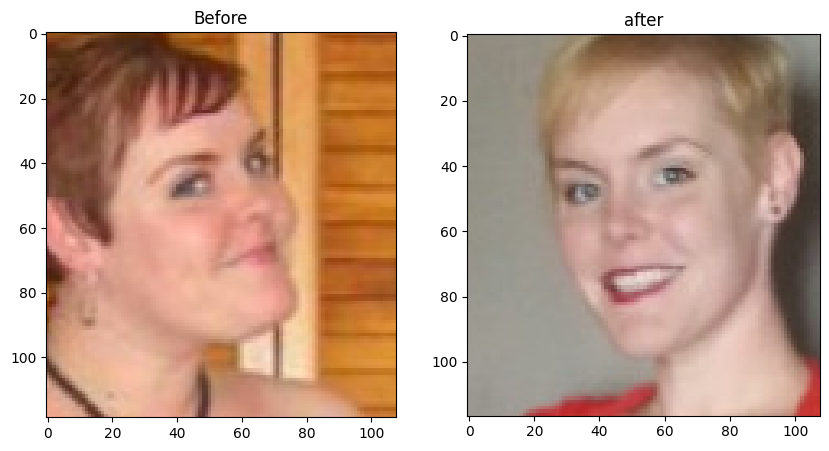

Pair index: 898
BMI before: 30.85
BMI after: 24.82


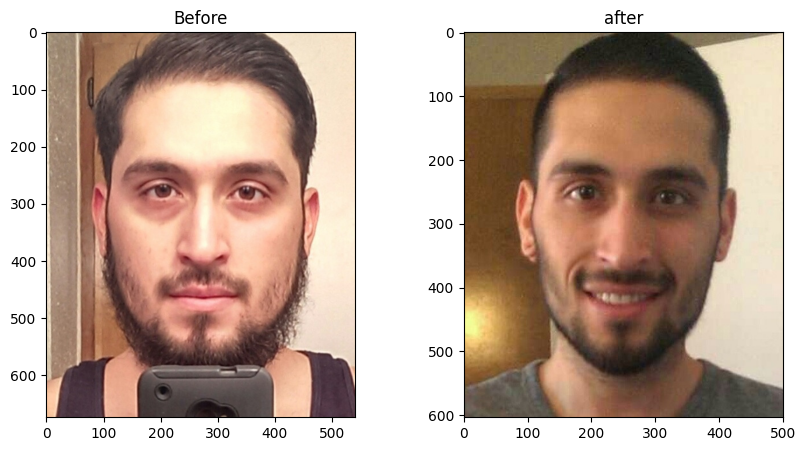

Pair index: 1720
BMI before: 41.96
BMI after: 29.86


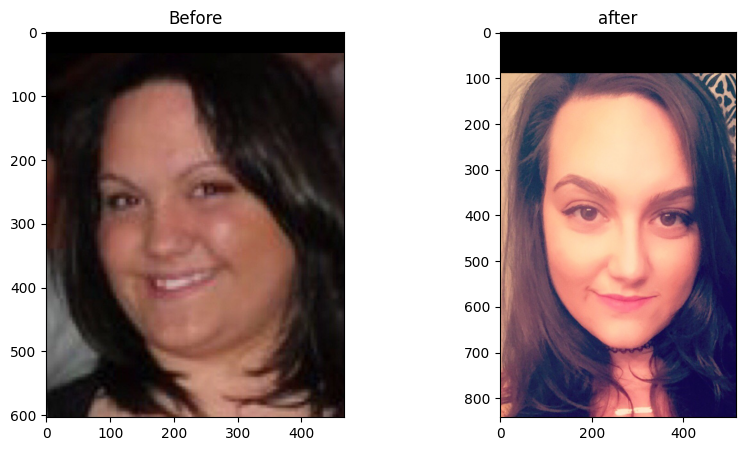

Pair index: 777
BMI before: 28.06
BMI after: 19.93


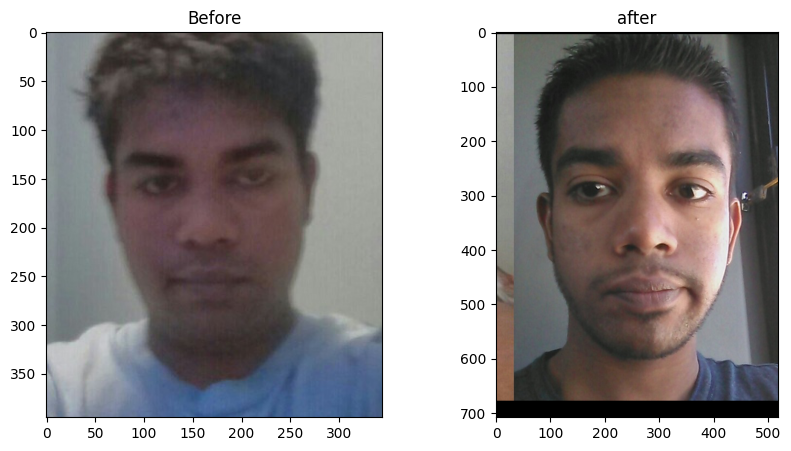

Pair index: 1968
BMI before: 33.0
BMI after: 25.82


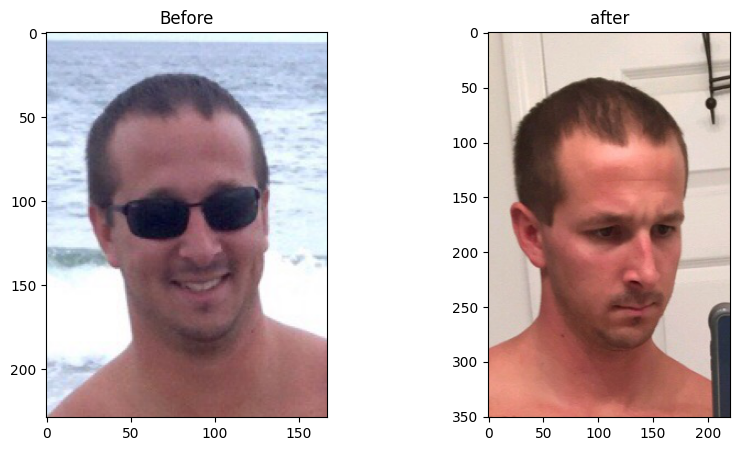

In [8]:
# Quick check
random.seed(97)
unique_pair_index = df_modeling['index_pair'].unique()
unique_pair_index = list(unique_pair_index)
select_index = values = random.sample(unique_pair_index, 5)


for pair_index in select_index:

    # get images path before/after
    print('Pair index:', pair_index)
    df_aux = df_modeling[df_modeling['index_pair'] == pair_index]
    df_aux.reset_index(drop=True, inplace=True)
    path_before = str(df_aux.loc[0, 'images_path'])
    path_after = df_aux.loc[1, 'images_path']
    print('BMI before:', round(df_aux.loc[0, 'bmi'],2))
    print('BMI after:', round(df_aux.loc[1, 'bmi'],2))

    # Show images
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    img_before = Image.open(path_before)
    ax1.imshow(img_before)
    ax1.set_title('Before')

    img_after = Image.open(path_after)
    ax2.imshow(img_after)
    ax2.set_title('after')
    plt.show()

In [9]:
# Create difference
df_modeling['BMI_before'] =  np.where(df_modeling['flag_before_after']=='after',df_modeling['bmi'].shift(1),0)
df_modeling['BMI_diff'] =  np.where(df_modeling['flag_before_after']=='after',df_modeling['BMI_before'] - df_modeling['bmi'] ,0)
# Create bins difference
bins = [0.5, 5.5, 10.5, 15.5]
df_modeling['BMI_diff_bins'] = pd.cut(df_modeling['BMI_diff'], bins=bins, labels=['0.5-5.5', '5.5-10.5', '10.5-15.5'])

In [10]:
display(df_modeling[['image_index','bmi','index_pair','flag_before_after','BMI_before',	'BMI_diff',	'BMI_diff_bins']].head(10))

,image_index,bmi,index_pair,flag_before_after,BMI_before,BMI_diff,BMI_diff_bins
0,0,34.207396,0,before,0.000000,0.000000,NaN
1,1,26.453720,0,after,34.207396,7.753676,5.5-10.5
2,2,34.967561,1,before,0.000000,0.000000,NaN
3,3,22.044766,1,after,34.967561,12.922794,10.5-15.5
4,6,25.845588,3,before,0.000000,0.000000,NaN
5,7,21.740701,3,after,25.845588,4.104888,0.5-5.5
6,8,30.615858,4,before,0.000000,0.000000,NaN
7,9,26.788876,4,after,30.615858,3.826982,0.5-5.5
8,10,38.732782,5,before,0.000000,0.000000,NaN
9,11,30.824839,5,after,38.732782,7.907943,5.5-10.5


In [11]:
# Split data into train and test
df_train_raw = df_modeling[df_modeling['is_training']==1]
df_test = df_modeling[df_modeling['is_training']==0]
# Check distrobution of classes training and test
# Split data into train and test
df_train_raw = df_modeling[df_modeling['is_training']==1]
df_test = df_modeling[df_modeling['is_training']==0]
print('Train:')
display(df_train_raw['BMI_category'].value_counts())
print('Test:')
display(df_test['BMI_category'].value_counts())

Train:


,count
BMI_category,
overweight,894
moderately obese,730
normal,543
very severely obese,523
severely obese,513
under-weight,7


Test:


,count
BMI_category,
overweight,193
very severely obese,172
moderately obese,155
normal,120
severely obese,112
under-weight,0


We will drop te categroy **under-weight**, since it only has 7 observations and is not present in the test partition use by the autors in the research paper.

In [12]:
# Delete under-weight
name_classes = ['normal', 'overweight', 'moderately obese', 'severely obese', 'very severely obese']
df_modeling = df_modeling[df_modeling['BMI_category'] != 'under-weight']
df_train_raw = df_train_raw[df_train_raw['BMI_category'] != 'under-weight']

# Number classes
name_classes = ['normal', 'overweight', 'moderately obese', 'severely obese', 'very severely obese']
mapping = {'normal': 0, 'overweight': 1,'moderately obese': 2,'severely obese':3, 'very severely obese': 4 }
df_modeling['BMI_category_encode'] = df_modeling['BMI_category'].map(mapping)
df_train_raw['BMI_category_encode'] = df_train_raw['BMI_category'].map(mapping)
df_test['BMI_category_encode'] = df_test['BMI_category'].map(mapping)
print('Train:')
display(df_train_raw['BMI_category'].value_counts())
display(df_train_raw['BMI_category_encode'].value_counts())

print('Test:')
display(df_test['BMI_category'].value_counts())
display(df_test['BMI_category_encode'].value_counts())

Train:


,count
BMI_category,
overweight,894
moderately obese,730
normal,543
very severely obese,523
severely obese,513
under-weight,0


,count
BMI_category_encode,
1.0,894
2.0,730
0.0,543
4.0,523
3.0,513


Test:


,count
BMI_category,
overweight,193
very severely obese,172
moderately obese,155
normal,120
severely obese,112
under-weight,0


,count
BMI_category_encode,
1.0,193
4.0,172
2.0,155
0.0,120
3.0,112


In [13]:
# Establish train and validation datasets to create holdout set of test
initial_rows  = df_train_raw.shape[0]
n_train = (df_train_raw.shape[0]) * 0.8
n_train = int(n_train)
print('Intial rows {}, it will be divide into training: {} and in validation {}'.format(initial_rows, n_train,initial_rows-n_train) )
# Split train and validation base on the index
# Train
df_train = df_train_raw[0:n_train]
y_train = df_train['BMI_category_encode'].to_numpy()
# Validation
df_val = df_train_raw[n_train: initial_rows]
y_val = df_val['BMI_category_encode'].to_numpy()
# Test
y_test =  df_test['BMI_category_encode'].to_numpy()

print('\nSanity check:')
print('In training shape features: {} and shape classes: {}  '.format(df_train.shape, y_train.shape ))
print('In validation shape features: {} and shape classes: {}  '.format(df_val.shape, y_val.shape ))

Intial rows 3203, it will be divide into training: 2562 and in validation 641

Sanity check:
In training shape features: (2562, 19) and shape classes: (2562,)  
In validation shape features: (641, 19) and shape classes: (641,)  


In [14]:
# Check distribution
print('train')
display(df_train[['bmi']].describe())
display(df_train[['gender']].value_counts(normalize=True))

print('val')
display(df_val[['bmi']].describe())
display(df_val[['gender']].value_counts(normalize=True))

print('test')
display(df_test[['bmi']].describe())
display(df_test[['gender']].value_counts(normalize=True))

train


,bmi
count,2562.000000
mean,32.421755
std,8.005026
min,18.651020
25%,26.289704
50%,31.008192
75%,36.974999
max,81.211930


,proportion
gender,
Male,0.611632
Female,0.388368


val


,bmi
count,641.000000
mean,32.641967
std,7.971775
min,19.483497
25%,26.541837
50%,30.845918
75%,37.741813
max,58.571712


,proportion
gender,
Male,0.558502
Female,0.441498


test


,bmi
count,752.000000
mean,33.698354
std,9.219863
min,18.651020
25%,26.872880
50%,31.947427
75%,38.867300
max,85.987061


,proportion
gender,
Male,0.567819
Female,0.432181


The distribution between the train and test used by the author in the paper is very similar, the test has a slightly higher average BMI compared to the train, but the quantiles of the BMI are very similar between the two datasets, which will not be an issue in the modeling step. In addition, there is more concentration of males in the train dataset with 60%, in contrast with the test 56%, it is something we need to consider in the model train process.

## 3. Modeling

## Preprocess datasets

In [15]:
# Check if a GPU is available
gpu_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpu_devices))

if gpu_devices:
    print("Success! TensorFlow is using the GPU:", gpu_devices[0].name)
else:
    print("TensorFlow cannot find a GPU. Double-check your Colab Runtime settings.")

Num GPUs Available:  1
Success! TensorFlow is using the GPU: /physical_device:GPU:0


In [16]:
# VGGFace mean pixel values (NOT ImageNet means)
VGGFACE_MEAN = [93.5940, 104.7624, 129.1863]  # BGR order
IMG_SIZE = (224, 224)

def preprocess_vggface(img_path):
    """
    Load and preprocess a face image for VGGFace.
    - Resize to 224x224
    - Convert to BGR (OpenCV default)
    - Subtract VGGFace mean (no /255 normalization)
    """
    # Load image
    img = cv2.imread(str(img_path))

    if img is None:
       raise ValueError(f"Could not load image: {img_path}")

    # Resize
    img = cv2.resize(img, IMG_SIZE)

    # Convert to float32
    img = img.astype(np.float32)

    # Subtract VGGFace channel means (BGR order)
    img[..., 0] -= VGGFACE_MEAN[0]  # B
    img[..., 1] -= VGGFACE_MEAN[1]  # G
    img[..., 2] -= VGGFACE_MEAN[2]  # R

    return img  # shape: (224, 224, 3)

In [17]:
# Preprecoses  images
X_train_list = []
X_val_list = []
X_test_list = []

# Training preprocess
for path_img in df_train.loc[:,'images_path']:
    X_train_list.append(preprocess_vggface(path_img))

# Val preprocess
for path_img in df_val.loc[:,'images_path']:
    X_val_list.append(preprocess_vggface(path_img))

# Test preprocess
for path_img in df_test.loc[:,'images_path']:
    X_test_list.append(preprocess_vggface(path_img))

# Transform to numpy array
X_train = np.array(X_train_list, dtype=np.float32)
X_val = np.array(X_val_list, dtype=np.float32)
X_test = np.array(X_test_list, dtype=np.float32)

# Change type of the classs
y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)

print('Features:')
print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

print('Classes:')
print(f"Train : {y_train.shape}")
print(f"Val   : {y_val.shape}")
print(f"Test  : {y_test.shape}")

Features:
Train : (2562, 224, 224, 3)
Val   : (641, 224, 224, 3)
Test  : (752, 224, 224, 3)
Classes:
Train : (2562,)
Val   : (641,)
Test  : (752,)


In [18]:
# Create dataframe use the paper ALL, M-M, F-F and M-F in test partition
df_male = df_test[df_test['gender'] == 'Male']
df_female = df_test[df_test['gender'] == 'Female']
# Create M-M
df_MM = df_male.sample(n=300, replace=False, random_state=97)
# Create F-F
df_FF = df_female.sample(n=300, replace=False, random_state=97)
# Create M-F
df_MF = df_male.sample(n=150, replace=False, random_state=97)
df_aux = df_female.sample(n=150, replace=False, random_state=97)
df_MF = pd.concat([df_MF,df_aux],axis=0)
# Creata ALL
df_ALL = pd.concat([df_MM, df_FF,df_MF ], axis=0)

display('Sanity Check:')
display('MM:',df_MM.shape )
display(df_MM['gender'].value_counts())
display('FF', df_FF.shape )
display(df_FF['gender'].value_counts())
display('MF', df_MF.shape)
display(df_MF['gender'].value_counts())
display('ALL',df_ALL.shape )
display(df_ALL['gender'].value_counts())

'Sanity Check:'

'MM:'

(300, 19)

,count
gender,
Male,300


'FF'

...

(300, 19)

,count
gender,
Male,150
Female,150


'ALL'

(900, 19)

,count
gender,
Male,450
Female,450


In [19]:
# Preprocess

X_MM_list = []
X_FF_list = []
X_MF_list = []
X_ALL_list = []

# MM preprocess
for path_img in df_MM.loc[:,'images_path']:
    X_MM_list.append(preprocess_vggface(path_img))

# FF preprocess
for path_img in df_FF.loc[:,'images_path']:
    X_FF_list.append(preprocess_vggface(path_img))

# MF preprocess
for path_img in df_MF.loc[:,'images_path']:
    X_MF_list.append(preprocess_vggface(path_img))

# ALL preprocess
for path_img in df_ALL.loc[:,'images_path']:
    X_ALL_list.append(preprocess_vggface(path_img))


# Transform to numpy array
X_MM = np.array(X_MM_list, dtype=np.float32)
X_FF = np.array(X_FF_list, dtype=np.float32)
X_MF = np.array(X_MF_list, dtype=np.float32)
X_ALL = np.array(X_ALL_list, dtype=np.float32)

# Target class
y_MM = df_MM['BMI_category_encode'].to_numpy()
y_FF = df_FF['BMI_category_encode'].to_numpy()
y_MF = df_MF['BMI_category_encode'].to_numpy()
y_ALL = df_ALL['BMI_category_encode'].to_numpy()

print('Features:')
print(f"MM : {X_MM.shape}")
print(f"FF   : {X_FF.shape}")
print(f"MF  : {X_MF.shape}")
print(f"ALL  : {X_ALL.shape}")

print('Classes:')
print(f"MM : {y_MM.shape}")
print(f"FF   : {y_FF.shape}")
print(f"MF  : {y_MF.shape}")
print(f"ALL  : {y_ALL.shape}")

Features:
MM : (300, 224, 224, 3)
FF   : (300, 224, 224, 3)
MF  : (300, 224, 224, 3)
ALL  : (900, 224, 224, 3)
Classes:
MM : (300,)
FF   : (300,)
MF  : (300,)
ALL  : (900,)


In [20]:
# Compute weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train,
)
# Convert to dictionary
class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(1.1752293577981652), 1: np.float64(0.7146443514644352), 2: np.float64(0.8773972602739726), 3: np.float64(1.2171021377672209), 4: np.float64(1.2683168316831683)}


In [21]:
def calculate_pred(model, X_features):
    # Predict
    predictions = model.predict(X_features, verbose=0)
    # Select the class with the highest probability
    pred_test_class_index = []
    for pred in predictions:
      class_index = np.argmax(pred)
      pred_test_class_index.append(class_index)
    # Return
    return pred_test_class_index

In [22]:
def calculate_paper_metrics(model, name_model):
  # Create
  comp_dict = {"Model": [] ,"ALL": [],"M-M": [],"F-F": [],"M-F":[] }
  # Add paper results
  comp_dict["Model"].append('Face-to-BMI (Paper)')
  comp_dict["ALL"].append(71.0)
  comp_dict["M-M"].append(73.7)
  comp_dict["F-F"].append(68.7)
  comp_dict["M-F"].append(70.7)

  # Name model
  comp_dict["Model"].append(name_model)
  # Calculate ALL
  pred_test_class_index = calculate_pred(model, X_ALL)
  comp_dict["ALL"].append(round(accuracy_score(y_ALL, pred_test_class_index),2)*100)
  # Calculate M-M
  pred_test_class_index = calculate_pred(model, X_MM)
  comp_dict["M-M"].append(round(accuracy_score(y_MM, pred_test_class_index),2)*100)
  # Calculate F-F
  pred_test_class_index = calculate_pred(model, X_FF)
  comp_dict["F-F"].append(round(accuracy_score(y_FF, pred_test_class_index),2)*100)
  # Calculate M-F
  pred_test_class_index = calculate_pred(model, X_MF)
  comp_dict["M-F"].append(round(accuracy_score(y_MF, pred_test_class_index),2)*100)
  return comp_dict

In [23]:
def show_graph_paper_gender(df_results, name_model):
  labels = ["ALL", "M-M", "F-F", "M-F"]
  x = np.arange(len(labels))
  width = 0.35
  # get results
  face_bmi = df_results.loc[0,labels]
  model_develop = df_results.loc[1,labels]

  plt.figure(figsize=(8, 5))

  plt.bar(x - width/2, face_bmi, width, label="Face-to-BMI (Paper)")
  plt.bar(x + width/2, model_develop, width, label=name_model)

  plt.ylabel("Accuracy (%)")
  plt.xlabel("Edge Type")
  plt.xticks(x, labels)
  plt.ylim(0, 100)
  plt.legend()

  # add values on top (like in paper)
  for i, v in enumerate(face_bmi):
      plt.text(i - width/2, v + 1, f"{v:.1f}", ha="center")

  for i, v in enumerate(model_develop):
      plt.text(i + width/2, v + 1, f"{v:.1f}", ha="center")

  plt.tight_layout()
  plt.show()

In [24]:
def calculate_BMI_diff(model, name_model, column_pred):
  # Create
  comp_dict = {"Model": [] ,"0.5-5.5": [],"5.5-10": [],"10.5-15.5": []}
  # Add paper results
  comp_dict["Model"].append('Face-to-BMI (Paper)')
  comp_dict["0.5-5.5"].append(56.2)
  comp_dict["5.5-10"].append(78.9)
  comp_dict["10.5-15.5"].append(82.7)
  # Name model
  comp_dict["Model"].append(name_model)

  # Calculate 0.5-5.5
  df_aux = df_test[df_test['BMI_diff_bins']=='0.5-5.5']
  comp_dict["0.5-5.5"].append(round(accuracy_score(df_aux['BMI_category_encode'], df_aux[column_pred]),2)*100)

  # Calculate 5.5-10
  df_aux = df_test[df_test['BMI_diff_bins']=='5.5-10.5']
  comp_dict["5.5-10"].append(round(accuracy_score(df_aux['BMI_category_encode'], df_aux[column_pred]),2)*100)

  # Calculate 10.5-15.5
  df_aux = df_test[df_test['BMI_diff_bins']=='10.5-15.5']
  comp_dict["10.5-15.5"].append(round(accuracy_score(df_aux['BMI_category_encode'], df_aux[column_pred]),2)*100)
  return comp_dict

In [25]:
def show_graph_paper_diff_BMI(df_results, name_model):
  labels = ["0.5-5.5", "5.5-10", "10.5-15.5"]
  x = np.arange(len(labels))
  width = 0.35
  # get results
  face_bmi = df_results.loc[0,labels]
  model_develop = df_results.loc[1,labels]

  plt.figure(figsize=(8, 5))

  plt.bar(x - width/2, face_bmi, width, label="Face-to-BMI (Paper)")
  plt.bar(x + width/2, model_develop, width, label=name_model)

  plt.ylabel("Accuracy (%)")
  plt.xlabel("Edge Type")
  plt.xticks(x, labels)
  plt.ylim(0, 100)
  plt.legend()

  # add values on top (like in paper)
  for i, v in enumerate(face_bmi):
      plt.text(i - width/2, v + 1, f"{v:.1f}", ha="center")

  for i, v in enumerate(model_develop):
      plt.text(i + width/2, v + 1, f"{v:.1f}", ha="center")

  plt.tight_layout()

### Backbone model

In [26]:
model_vgg   = DeepFace.build_model("VGG-Face")
base = model_vgg.model
# Check layer of the model
for i, layer in enumerate(base.layers):
    print(f"{i:3d} | {layer.name:35s} | {str(layer.output_shape):25s} | trainable={layer.trainable}")

  0 | zero_padding2d_input                | [(None, 224, 224, 3)]     | trainable=True
  1 | zero_padding2d                      | (None, 226, 226, 3)       | trainable=True
  2 | conv2d                              | (None, 224, 224, 64)      | trainable=True
  3 | zero_padding2d_1                    | (None, 226, 226, 64)      | trainable=True
  4 | conv2d_1                            | (None, 224, 224, 64)      | trainable=True
  5 | max_pooling2d                       | (None, 112, 112, 64)      | trainable=True
  6 | zero_padding2d_2                    | (None, 114, 114, 64)      | trainable=True
  7 | conv2d_2                            | (None, 112, 112, 128)     | trainable=True
  8 | zero_padding2d_3                    | (None, 114, 114, 128)     | trainable=True
  9 | conv2d_3                            | (None, 112, 112, 128)     | trainable=True
 10 | max_pooling2d_1                     | (None, 56, 56, 128)       | trainable=True
 11 | zero_padding2d_4                    |

## 3.1 Modeling aproach 1: Baseline

In [27]:
# Take intermediate layer
x = base.layers[-3].output

# Add custom classifier head
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(len(name_classes), activation='softmax')(x)

model_tune = Model(inputs=base.input, outputs=output)

In [28]:
# Train only the new classifier head first.
for layer in model_tune.layers:
    layer.trainable = False
print("Freeze layers:", sum(1 for l in model_tune.layers if l.trainable==False))
print("Trainable layers:", sum(1 for l in model_tune.layers if l.trainable))

Freeze layers: 37
Trainable layers: 0


In [29]:
# Compile model
model_tune.compile(
    optimizer=Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint("best_phase1.keras", save_best_only=True, verbose=1)
]
# Tuning process
history = model_tune.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/50
81/81 [==============================] - ETA: 0s - loss: 21.2388 - accuracy: 0.2118
Epoch 1: val_loss improved from inf to 9.56039, saving model to best_phase1.keras
81/81 [==============================] - 19s 185ms/step - loss: 21.2388 - accuracy: 0.2118 - val_loss: 9.5604 - val_accuracy: 0.2263 - lr: 1.0000e-04
Epoch 2/50
80/81 [============================>.] - ETA: 0s - loss: 21.1639 - accuracy: 0.2127
Epoch 2: val_loss did not improve from 9.56039
81/81 [==============================] - 11s 139ms/step - loss: 21.1561 - accuracy: 0.2127 - val_loss: 9.5604 - val_accuracy: 0.2263 - lr: 1.0000e-04
Epoch 3/50
80/81 [============================>.] - ETA: 0s - loss: 20.9600 - accuracy: 0.2141
Epoch 3: val_loss did not improve from 9.56039
81/81 [==============================] - 11s 141ms/step - loss: 20.9552 - accuracy: 0.2141 - val_loss: 9.5604 - val_accuracy: 0.2263 - lr: 1.0000e-04
Epoch 4/50
80/81 [============================>.] - ETA: 0s - loss: 21.0961 - accuracy: 0

In [30]:
# Calculate predictions in train
df_train['model1_pred'] = calculate_pred(model_tune, X_train)
# Calcualte predictions test
df_test['model1_pred'] = calculate_pred(model_tune, X_test)

In [31]:
print('Train results:')
metrics_train_model_1 = classification_report(y_train, df_train['model1_pred'])
print(metrics_train_model_1)
print("Accuracy: {:.3f}".format(accuracy_score(y_train, df_train['model1_pred'])))

print('\nTest results:')
metrics_test_model_1 = classification_report(y_test, df_test['model1_pred'])
print(metrics_test_model_1)
print("Accuracy: {:.3f}".format(accuracy_score(y_test, df_test['model1_pred'])))

Train results:
              precision    recall  f1-score   support

         0.0       0.15      0.14      0.15       436
         1.0       0.27      0.51      0.36       717
         2.0       0.23      0.11      0.15       584
         3.0       0.15      0.16      0.15       421
         4.0       0.18      0.06      0.09       404

    accuracy                           0.22      2562
   macro avg       0.20      0.19      0.18      2562
weighted avg       0.21      0.22      0.20      2562

Accuracy: 0.224

Test results:
              precision    recall  f1-score   support

         0.0       0.10      0.10      0.10       120
         1.0       0.23      0.46      0.31       193
         2.0       0.21      0.12      0.15       155
         3.0       0.07      0.07      0.07       112
         4.0       0.24      0.07      0.11       172

    accuracy                           0.18       752
   macro avg       0.17      0.16      0.15       752
weighted avg       0.18      0.

Gender


,Model,ALL,M-M,F-F,M-F
0,Face-to-BMI (Paper),71.0,73.7,68.7,70.7
1,Model_1(Baseline),15.0,19.0,14.0,14.0


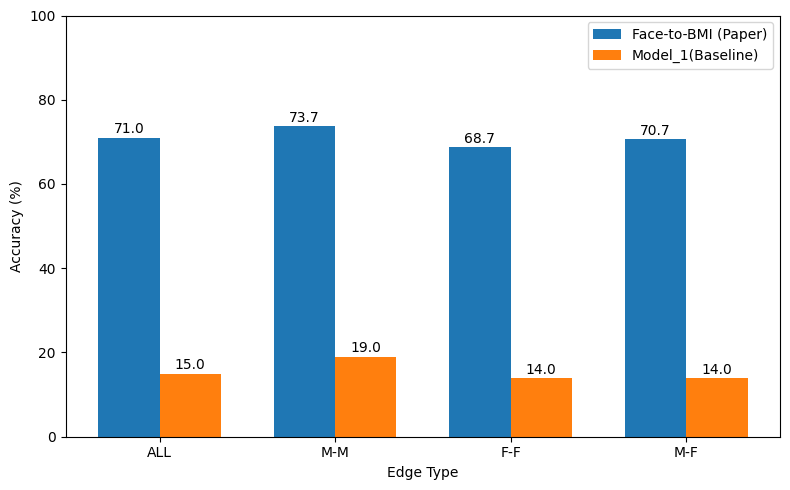

BMI_diff


,Model,0.5-5.5,5.5-10,10.5-15.5
0,Face-to-BMI (Paper),56.2,78.9,82.7
1,Model_1(Baseline),24.0,21.0,18.0


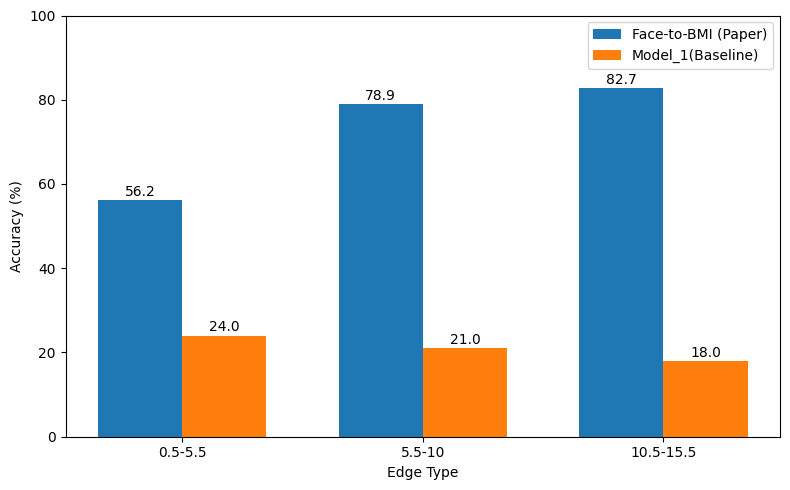

In [32]:
# Call gender graph

dict_results = calculate_paper_metrics(model_tune,'Model_1(Baseline)')
df_results = pd.DataFrame(dict_results)
print('Gender')
display(df_results)
dict_results = show_graph_paper_gender(df_results,'Model_1(Baseline)')

# Call BMI difference
dict_results_BMI_diff = calculate_BMI_diff(model_tune,'Model_1(Baseline)','model1_pred')
print('BMI_diff')
df_results_BMI_diff = pd.DataFrame(dict_results_BMI_diff)
display(df_results_BMI_diff)
dict_results = show_graph_paper_diff_BMI(df_results_BMI_diff,'Model_1(Baseline)')

## 3.2 Modeling aproach 2: Baseline

In [33]:
# Cut at last pooling layer
cut = base.get_layer("max_pooling2d_4").output
x   = GlobalAveragePooling2D()(cut)

# Custom head for BMI regression (4 extra layers)
# Block 1
x = Dense(512, activation='relu')(x)  # addtional layer 1
x = BatchNormalization()(x) # addtional layer 2
x = Dropout(0.6)(x)
# Block 2
x = Dense(256, activation='relu')(x) # addtional layer 3
x = BatchNormalization()(x) # addtional layer 4
x = Dropout(0.5)(x)
output = Dense(len(name_classes), activation='softmax', name='bmi_output')(x)


model2_tune = Model(inputs=base.input, outputs=output)
print("Freeze layers:", sum(1 for l in model_tune.layers if l.trainable==False))
print("Trainable layers:", sum(1 for l in model_tune.layers if l.trainable))

Freeze layers: 37
Trainable layers: 0


In [34]:
# Extract the addtional layers add
last_4_layers = model_tune.layers[-8:]

# 3. Print a custom summary for these layers
print(f"{'Layer (type)':<60} {'Output Shape':<25} {'Param #'}")
print("=" * 120)

total_params = 0

for layer in last_4_layers:
    # Format layer name and class type
    layer_info = f"{layer.name} ({layer.__class__.__name__})"

    # Handle multiple output shapes (if applicable)
    if isinstance(layer.output_shape, list):
        output_shape = str(layer.output_shape[0])
    else:
        output_shape = str(layer.output_shape)

    # Get parameter count
    params = layer.count_params()
    total_params += params

    print(f"{layer_info:<60} {output_shape:<25} {params}")

print("=" * 120)
print(f"Total params addtional layers add to be tune step: {total_params:,}")

Layer (type)                                                 Output Shape              Param #
zero_padding2d_12 (ZeroPadding2D)                            (None, 16, 16, 512)       0
conv2d_12 (Conv2D)                                           (None, 14, 14, 512)       2359808
max_pooling2d_4 (MaxPooling2D)                               (None, 7, 7, 512)         0
conv2d_13 (Conv2D)                                           (None, 1, 1, 4096)        102764544
dropout (Dropout)                                            (None, 1, 1, 4096)        0
dense (Dense)                                                (None, 1, 1, 256)         1048832
dropout_2 (Dropout)                                          (None, 1, 1, 256)         0
dense_1 (Dense)                                              (None, 1, 1, 5)           1285
Total params addtional layers add to be tune step: 106,174,469


In [35]:
# ─── PHASE 1: Train head only (frozen base) ──────────────────────
base.trainable = False

model2_tune.compile(
    optimizer=Adam(learning_rate=1e-3),  # higher LR — only head trains
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint("best_phase1.keras", save_best_only=True, verbose=1)
]

print("=== PHASE 1: Training head only ===")
history1 = model2_tune.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks
)


# ─── PHASE 2: Unfreeze & fine-tune top layers (lower LR) ──────────
freeze = True
for layer in base.layers:
    if layer.name == "zero_padding2d_12":  # unfreeze from block 5
        freeze = False
    layer.trainable = not freeze

model2_tune.compile(
    optimizer=Adam(learning_rate=1e-5),  # much lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks2 = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-8, verbose=1),
    ModelCheckpoint("best_phase2.keras", save_best_only=True, verbose=1)
]

print("=== PHASE 2: Fine-tuning top layers ===")
history2 = model2_tune.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    class_weight=class_weights,
    callbacks=callbacks2
)

=== PHASE 1: Training head only ===
Epoch 1/30
80/81 [============================>.] - ETA: 0s - loss: 2.2972 - accuracy: 0.2719
Epoch 1: val_loss improved from inf to 1.77407, saving model to best_phase1.keras
81/81 [==============================] - 13s 129ms/step - loss: 2.2955 - accuracy: 0.2724 - val_loss: 1.7741 - val_accuracy: 0.3541 - lr: 0.0010
Epoch 2/30
80/81 [============================>.] - ETA: 0s - loss: 1.7557 - accuracy: 0.3363
Epoch 2: val_loss improved from 1.77407 to 1.53510, saving model to best_phase1.keras
81/81 [==============================] - 10s 121ms/step - loss: 1.7549 - accuracy: 0.3365 - val_loss: 1.5351 - val_accuracy: 0.3744 - lr: 0.0010
Epoch 3/30
80/81 [============================>.] - ETA: 0s - loss: 1.6124 - accuracy: 0.3730
Epoch 3: val_loss improved from 1.53510 to 1.45140, saving model to best_phase1.keras
81/81 [==============================] - 10s 121ms/step - loss: 1.6131 - accuracy: 0.3728 - val_loss: 1.4514 - val_accuracy: 0.3869 - lr: 

In [36]:
# Calculate predictions in train
df_train['model2_pred'] = calculate_pred(model2_tune, X_train)
# Calcualte predictions test
df_test['model2_pred'] = calculate_pred(model2_tune, X_test)

In [37]:
print('Train results:')
metrics_train_model_1 = classification_report(y_train, df_train['model2_pred'])
print(metrics_train_model_1)
print("Accuracy: {:.3f}".format(accuracy_score(y_train, df_train['model2_pred'])))

print('\nTest results:')
metrics_test_model_1 = classification_report(y_test, df_test['model2_pred'])
print(metrics_test_model_1)
print("Accuracy: {:.3f}".format(accuracy_score(y_test, df_test['model2_pred'])))

Train results:
              precision    recall  f1-score   support

         0.0       0.58      0.88      0.70       436
         1.0       0.75      0.47      0.58       717
         2.0       0.65      0.55      0.60       584
         3.0       0.64      0.60      0.62       421
         4.0       0.63      0.88      0.73       404

    accuracy                           0.64      2562
   macro avg       0.65      0.68      0.65      2562
weighted avg       0.66      0.64      0.63      2562

Accuracy: 0.644

Test results:
              precision    recall  f1-score   support

         0.0       0.43      0.60      0.50       120
         1.0       0.39      0.25      0.30       193
         2.0       0.32      0.31      0.31       155
         3.0       0.21      0.23      0.22       112
         4.0       0.51      0.55      0.53       172

    accuracy                           0.38       752
   macro avg       0.37      0.39      0.37       752
weighted avg       0.38      0.

Gender


,Model,ALL,M-M,F-F,M-F
0,Face-to-BMI (Paper),71.0,73.7,68.7,70.7
1,Model_2,38.0,37.0,40.0,38.0


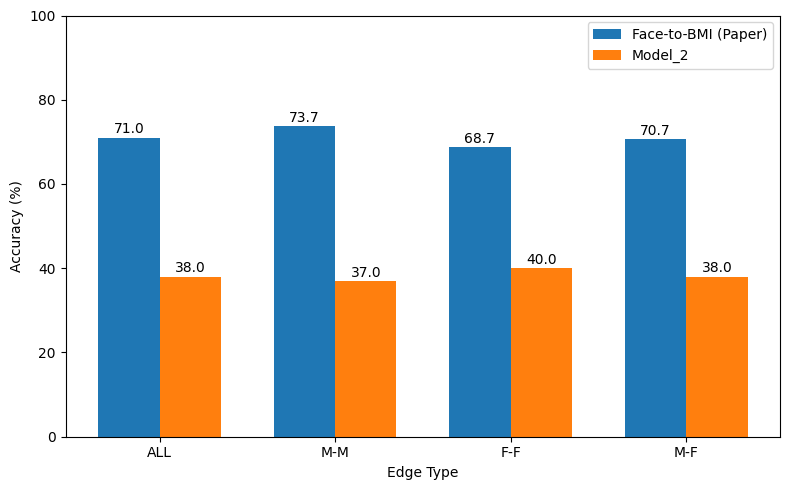

BMI_diff


,Model,0.5-5.5,5.5-10,10.5-15.5
0,Face-to-BMI (Paper),56.2,78.9,82.7
1,Model_2,43.0,38.0,35.0


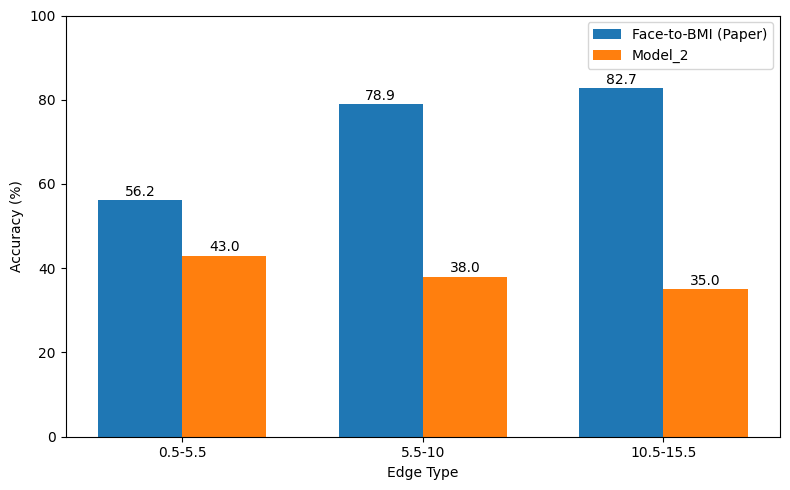

In [38]:
# Call gender graph

dict_results = calculate_paper_metrics(model2_tune,'Model_2')
df_results = pd.DataFrame(dict_results)
print('Gender')
display(df_results)
dict_results = show_graph_paper_gender(df_results,'Model_2')

# Call BMI difference
dict_results_BMI_diff = calculate_BMI_diff(model2_tune,'Model_2','model2_pred')
print('BMI_diff')
df_results_BMI_diff = pd.DataFrame(dict_results_BMI_diff)
display(df_results_BMI_diff)
dict_results = show_graph_paper_diff_BMI(df_results_BMI_diff,'Model_2')